Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']
Training Data: (455, 30)
Testing Data: (114, 30)

AdaBoost Accuracy: 0.956140350877193

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



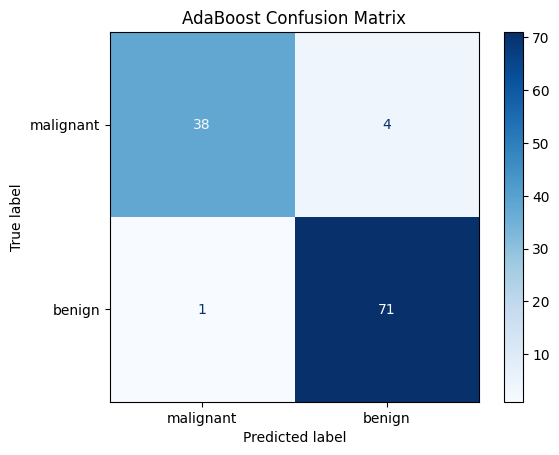


Top 10 Important Features:
                 Feature  Importance
21         worst texture    0.124860
27  worst concave points    0.121384
13            area error    0.101582
20          worst radius    0.094089
5       mean compactness    0.062895
4        mean smoothness    0.057885
23            worst area    0.053086
24      worst smoothness    0.051761
28        worst symmetry    0.051445
1           mean texture    0.045747


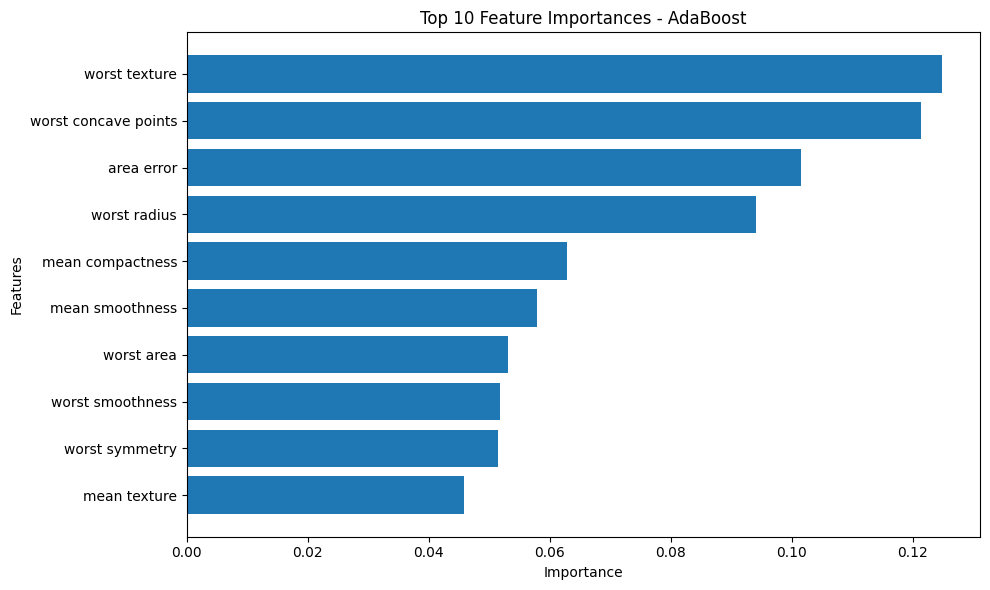

In [1]:
# Step 1: Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Step 2: Load the dataset

data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Target Classes:", data.target_names)

# Step 3: Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# Step 4: Create the base learner

base_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

# Step 5: Create the AdaBoost model

model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# Step 6: Train the model

model.fit(X_train, y_train)

# Step 7: Make predictions

y_pred = model.predict(X_test)

# Step 8: Evaluate the model

accuracy = accuracy_score(y_test, y_pred)

print("\nAdaBoost Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

# Step 9: Display confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap="Blues")
plt.title("AdaBoost Confusion Matrix")
plt.show()

# Step 10: Display feature importance

feature_importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features:")
print(importance_df.head(10))

# Plot top 10 important features

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"].head(10)[::-1],
    importance_df["Importance"].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances - AdaBoost")
plt.tight_layout()
plt.show()